# Yulu Shared Electric Cycles — Hypothesis Testing Case Study

**Business Case Study | EDA, 2-Sample T-Test, ANOVA, Chi-Square Test**

## 1. Problem Statement

Yulu has seen a considerable dip in revenue and wants to understand **which factors significantly affect demand** for its shared electric cycles in the Indian market, and **how well** those factors describe/explain demand. This notebook:

1. Explores and cleans the rental dataset.
2. Examines relationships between `count` (total rentals) and factors like `workingday`, `season`, `weather`.
3. Runs formal hypothesis tests:
   - **2-sample t-test** — does `workingday` affect rental count?
   - **One-way ANOVA** — does `season` affect rental count? Does `weather` affect rental count?
   - **Chi-square test of independence** — is `weather` dependent on `season`?
4. Converts findings into **actionable business recommendations**.


In [1]:
from IPython.display import display, HTML
display(HTML("<style>pre { white-space: pre-wrap !important; }</style>"))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
np.random.seed(42)

df = pd.read_csv("bike_sharing.csv")
print(df.head())


              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


## 2. Basic Data Checks

In [2]:
print("Shape of dataset:", df.shape)
print()
df.info()


Shape of dataset: (10886, 12)

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Duplicate rows: 0


In [4]:
df["datetime"] = pd.to_datetime(df["datetime"])
cat_cols = ["season", "holiday", "workingday", "weather"]
for c in cat_cols:
    df[c] = df[c].astype("category")
print(df.dtypes)


datetime      datetime64[us]
season              category
holiday             category
workingday          category
weather             category
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object


In [5]:
print("Statistical summary (numeric columns):")
print(df.describe().T)


Statistical summary (numeric columns):
              count                        mean                  min  \
datetime      10886  2011-12-27 05:56:22.399412  2011-01-01 00:00:00   
temp        10886.0                    20.23086                 0.82   
atemp       10886.0                   23.655084                 0.76   
humidity    10886.0                    61.88646                  0.0   
windspeed   10886.0                   12.799395                  0.0   
casual      10886.0                   36.021955                  0.0   
registered  10886.0                  155.552177                  0.0   
count       10886.0                  191.574132                  1.0   

                            25%                  50%                  75%  \
datetime    2011-07-02 07:15:00  2012-01-01 20:30:00  2012-07-01 12:45:00   
temp                      13.94                 20.5                26.24   
atemp                    16.665                24.24                31.06   
humi

**Observations**
- **10,886 hourly records**, no missing values, no duplicate rows — data is clean.
- `season`, `holiday`, `workingday`, `weather` are categorical codes and are cast to `category` dtype; `datetime` is parsed to a proper timestamp.
- `count` = `casual` + `registered` ranges from 1 to 977 rentals/hour, mean ≈191, median ≈145 — **mean > median**, so `count` is **right-skewed** (confirmed below).
- `temp` ranges ~0.8-41°C, `humidity` 0-100%, `windspeed` 0-57 — all sensible physical ranges, no obviously invalid values.
- `weather` category **4** (heavy rain/snow) has only **1 observation** out of 10,886 — an extremely rare condition; we flag this as a small-sample caveat wherever `weather` is used as a group.

## 3. Non-Graphical Analysis — Value Counts

In [6]:
for col in ["season", "holiday", "workingday", "weather"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index())
    print()


--- season ---
season
1    2686
2    2733
3    2733
4    2734
Name: count, dtype: int64

--- holiday ---
holiday
0    10575
1      311
Name: count, dtype: int64

--- workingday ---
workingday
0    3474
1    7412
Name: count, dtype: int64

--- weather ---
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64



**Observations**
- Seasons are almost evenly represented (~2,700 records each).
- **~68% of records are working days**, ~32% are non-working (weekends + holidays combined). Only ~2.9% are holidays specifically.
- **Weather 1 (Clear)** dominates (~66% of hours), Weather 2 (Mist/Cloudy) ~26%, Weather 3 (Light snow/rain) ~8%, Weather 4 (Heavy rain/snow) is a single hour.

## 4. Missing Value & Outlier Detection

No missing values were found. We check the continuous variables (`temp`, `atemp`, `humidity`, `windspeed`, `casual`, `registered`, `count`) for outliers.

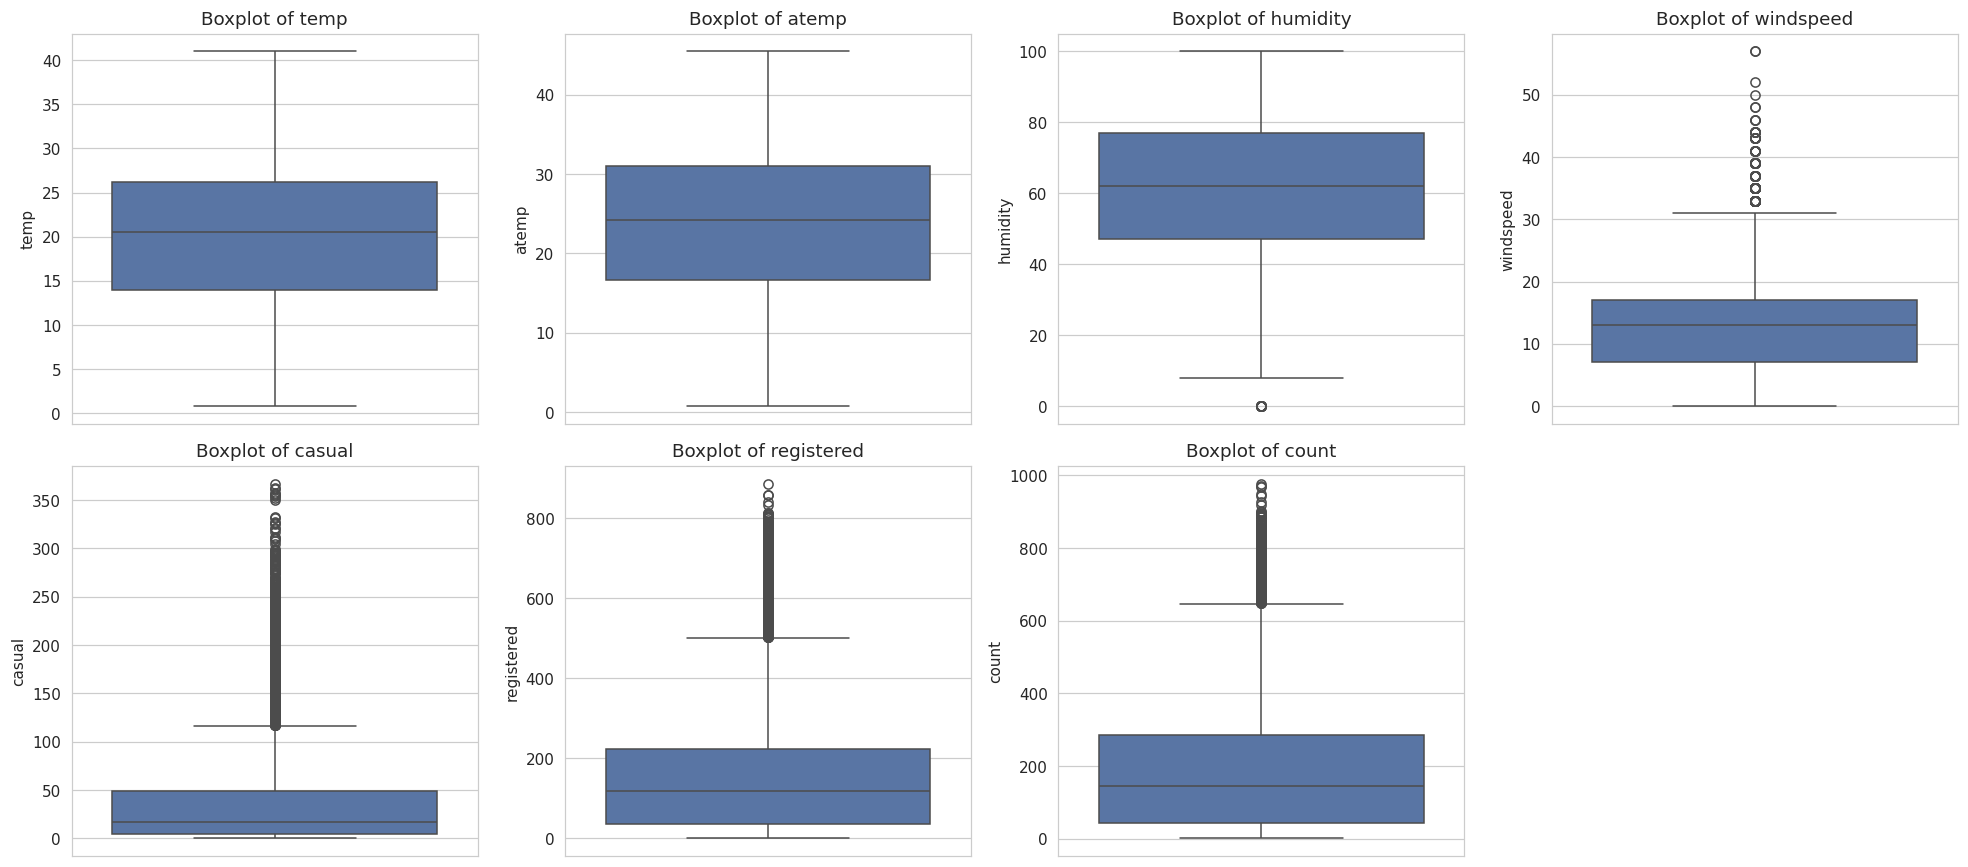

In [7]:
num_cols = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot of {col}")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()


In [8]:
def outlier_summary(col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "Lower": lower, "Upper": upper,
            "n_outliers": n_out, "pct_outliers": round(n_out/len(df)*100, 2)}

outlier_table = pd.DataFrame({c: outlier_summary(c) for c in num_cols}).T
print(outlier_table)


                 Q1        Q3       IQR     Lower     Upper  n_outliers  \
temp        13.9400   26.2400   12.3000   -4.5100   44.6900         0.0   
atemp       16.6650   31.0600   14.3950   -4.9275   52.6525         0.0   
humidity    47.0000   77.0000   30.0000    2.0000  122.0000        22.0   
windspeed    7.0015   16.9979    9.9964   -7.9931   31.9925       227.0   
casual       4.0000   49.0000   45.0000  -63.5000  116.5000       749.0   
registered  36.0000  222.0000  186.0000 -243.0000  501.0000       423.0   
count       42.0000  284.0000  242.0000 -321.0000  647.0000       300.0   

            pct_outliers  
temp                0.00  
atemp               0.00  
humidity            0.20  
windspeed           2.09  
casual              6.88  
registered          3.89  
count               2.76  


**Observations**
- **`windspeed`, `casual`, `registered`, and `count`** show the most outliers — all on the **high side**, i.e., unusually busy hours (rush hour, good-weather peak demand) or unusually windy hours. These are genuine demand spikes, not data errors, so we **keep them** rather than remove/clip — they matter for understanding peak-demand behavior, which is directly relevant to Yulu's business question.
- `temp`, `atemp`, `humidity` show few or no outliers — expected, as weather variables vary smoothly.
- We do **not** treat any of these as data-entry errors requiring removal.

## 5. Univariate Analysis

### 5.1 Continuous variables — distribution

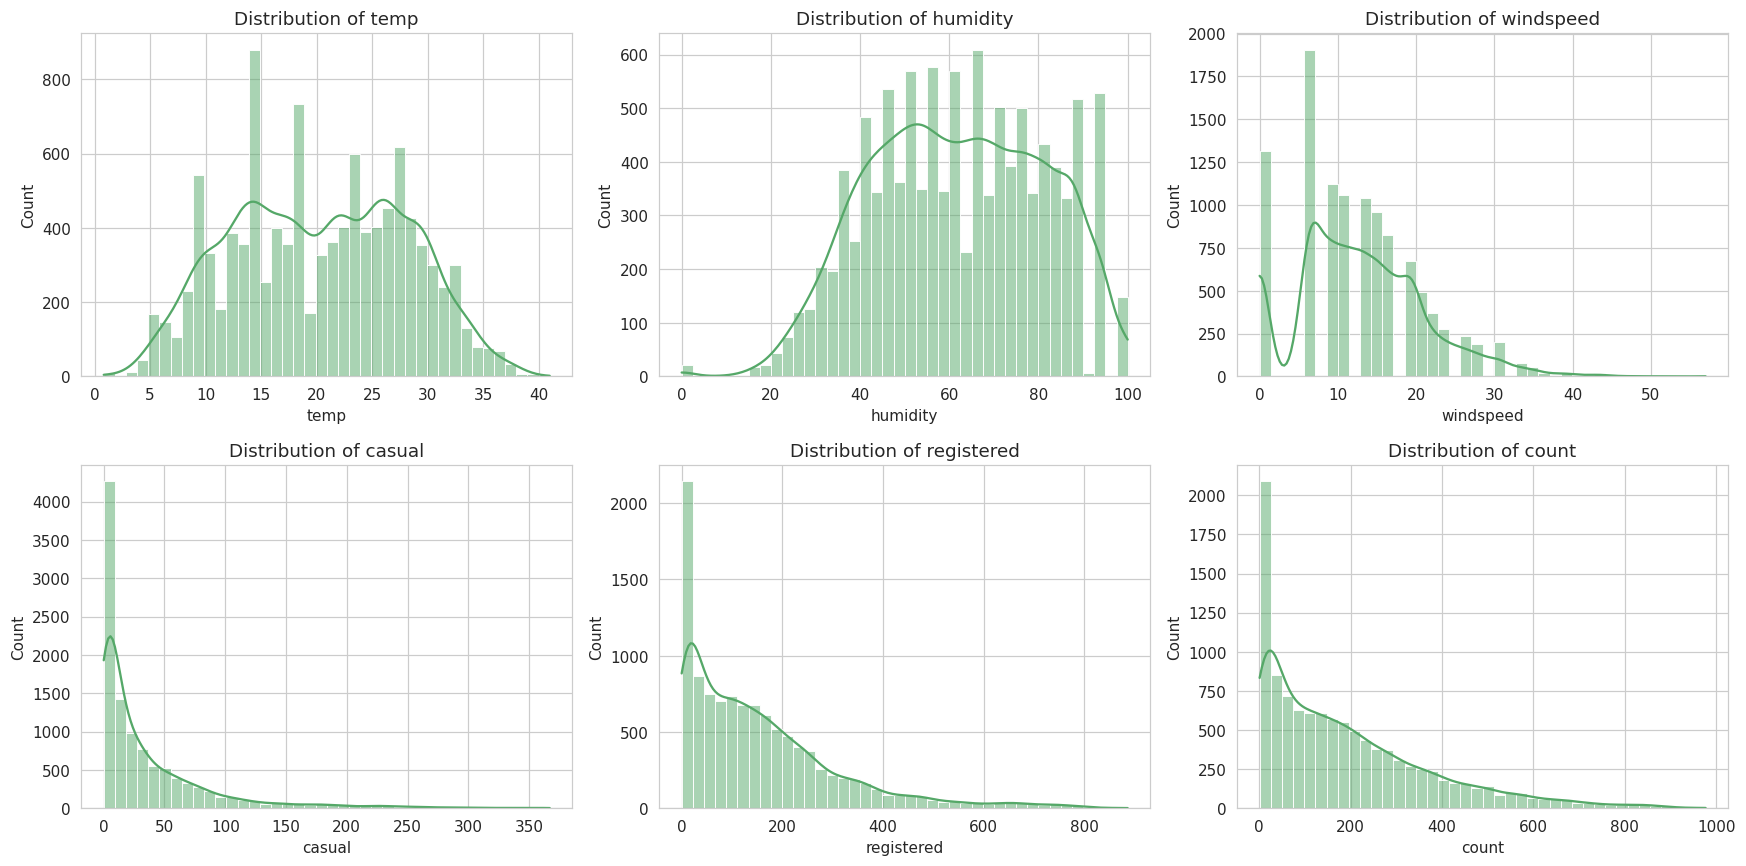

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
dist_cols = ["temp", "humidity", "windspeed", "casual", "registered", "count"]
for ax, col in zip(axes.flatten(), dist_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#55A868", bins=40)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


### 5.2 Categorical variables — count plots

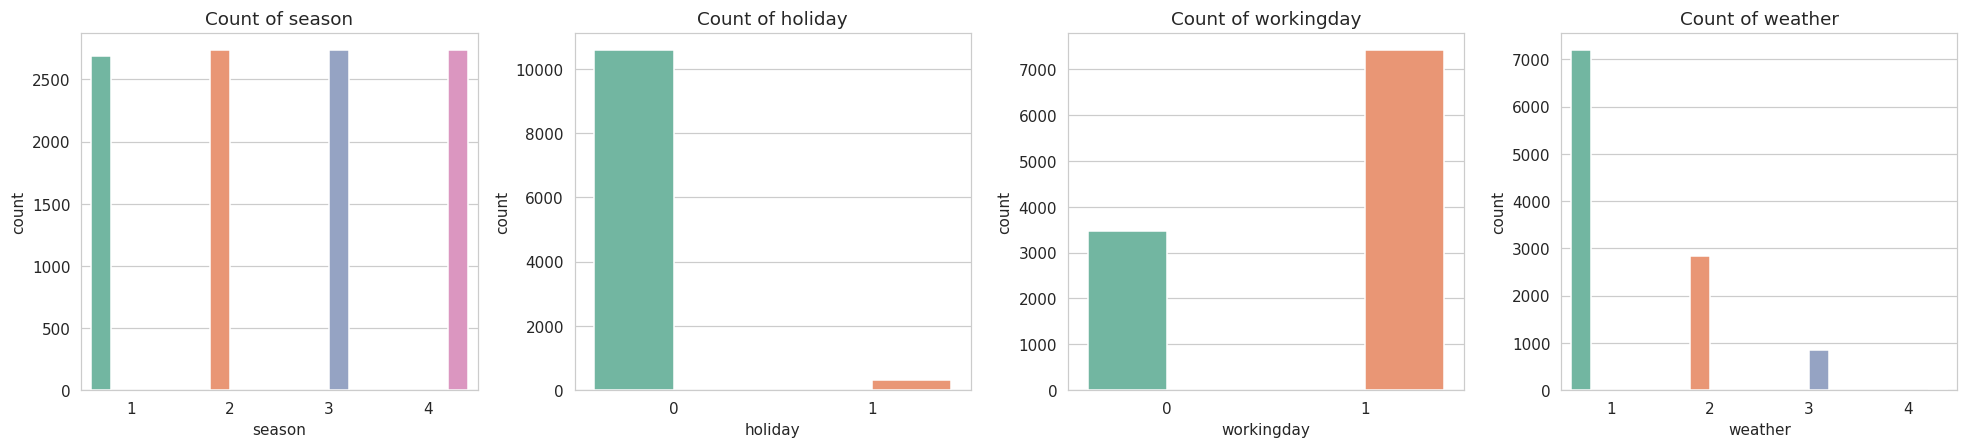

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, col in zip(axes, ["season", "holiday", "workingday", "weather"]):
    sns.countplot(x=df[col], ax=ax, hue=df[col], palette="Set2", legend=False)
    ax.set_title(f"Count of {col}")
plt.tight_layout()
plt.show()


**Observations**
- `temp` is roughly symmetric/bimodal (India's hot & mild seasons), `humidity` is left-skewed (frequently high), `windspeed` is right-skewed with a spike at 0 (many calm hours, some measurement rounding to 0).
- `casual`, `registered`, and `count` are all **strongly right-skewed** — most hours see modest rental volumes, with a long tail of high-demand hours (rush hours, weekends with good weather). `registered` riders far outnumber `casual` riders on average — Yulu's core, repeat-user base drives most volume.
- Categorical counts confirm balanced seasons, workingday-majority data, and clear-weather-majority data (as seen in section 3).

## 6. Bivariate Analysis — Demand (`count`) vs Key Factors

### 6.1 Count vs Working Day

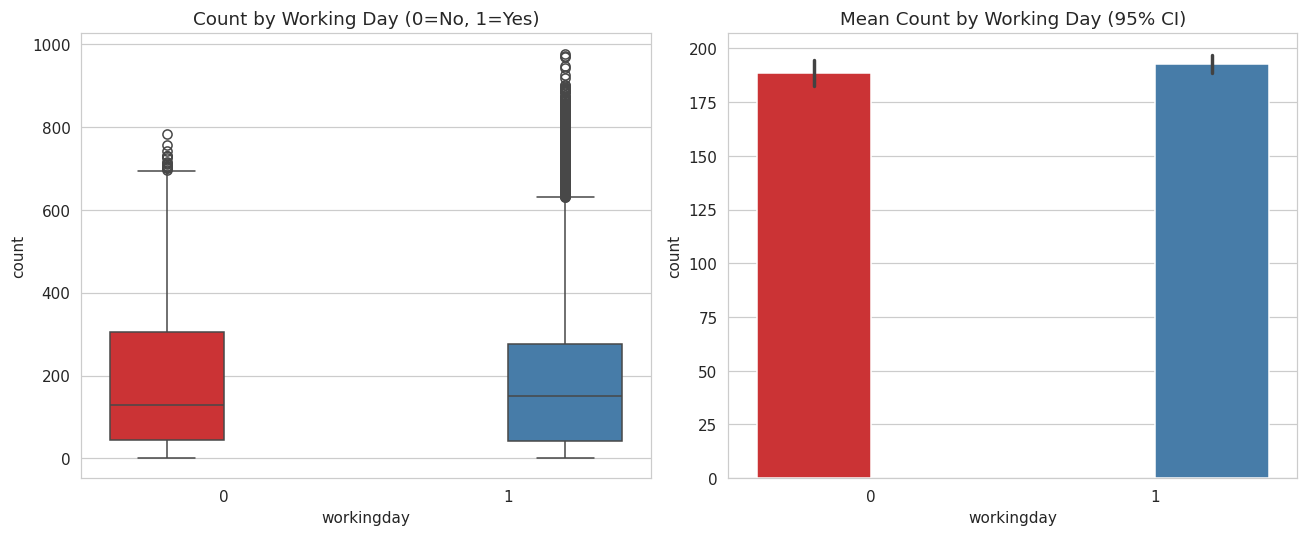

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x="workingday", y="count", data=df, ax=axes[0], hue="workingday", palette="Set1", legend=False)
axes[0].set_title("Count by Working Day (0=No, 1=Yes)")
sns.barplot(x="workingday", y="count", data=df, ax=axes[1], hue="workingday", palette="Set1", legend=False, estimator="mean", errorbar=("ci",95))
axes[1].set_title("Mean Count by Working Day (95% CI)")
plt.tight_layout()
plt.show()


### 6.2 Count vs Season

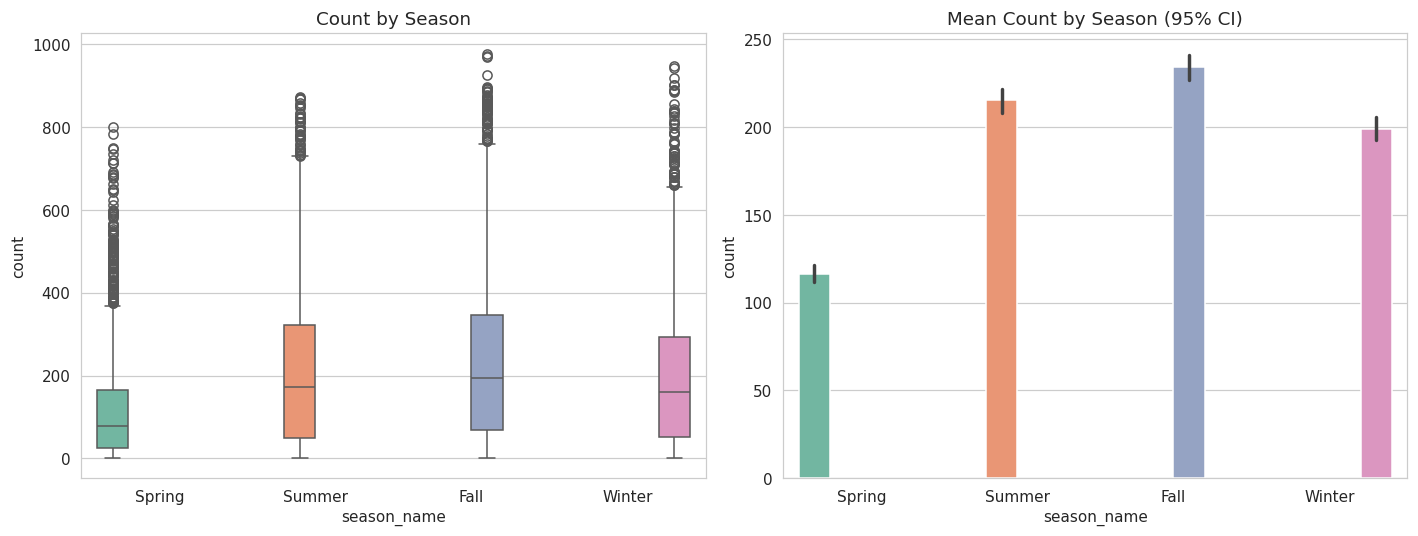

In [12]:
season_labels = {1:"Spring", 2:"Summer", 3:"Fall", 4:"Winter"}
df["season_name"] = df["season"].map(season_labels)
order_season = ["Spring","Summer","Fall","Winter"]

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(x="season_name", y="count", data=df, order=order_season, ax=axes[0], hue="season_name", palette="Set2", legend=False)
axes[0].set_title("Count by Season")
sns.barplot(x="season_name", y="count", data=df, order=order_season, ax=axes[1], hue="season_name", palette="Set2", legend=False, estimator="mean", errorbar=("ci",95))
axes[1].set_title("Mean Count by Season (95% CI)")
plt.tight_layout()
plt.show()


### 6.3 Count vs Weather

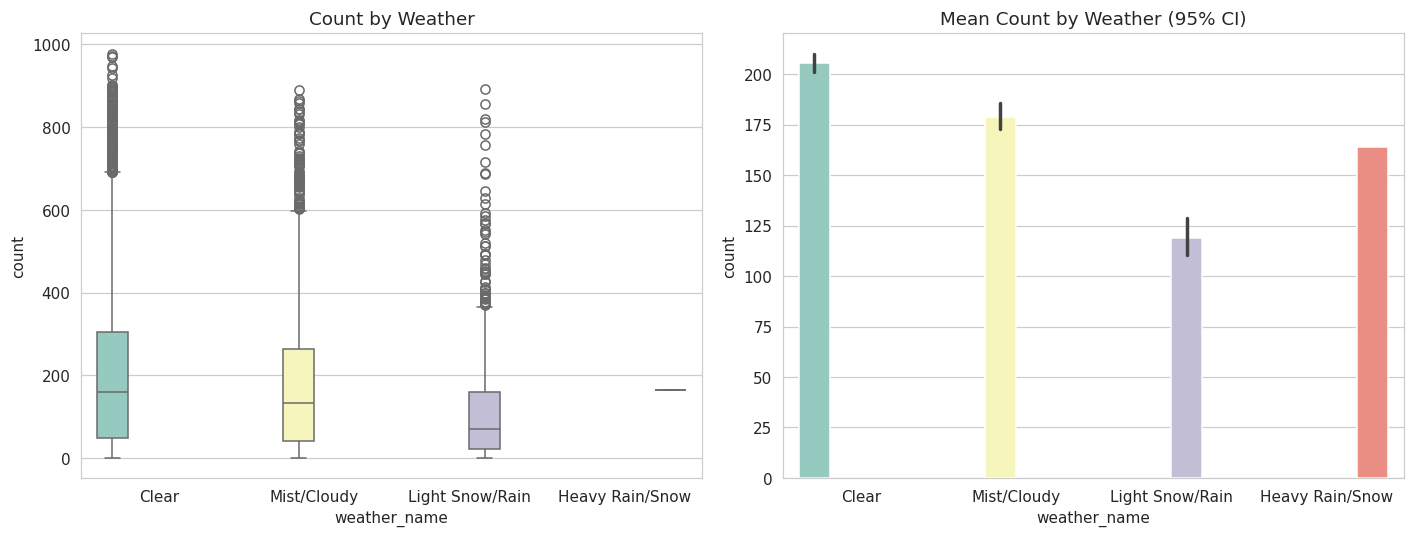

In [13]:
weather_labels = {1:"Clear", 2:"Mist/Cloudy", 3:"Light Snow/Rain", 4:"Heavy Rain/Snow"}
df["weather_name"] = df["weather"].map(weather_labels)
order_weather = ["Clear","Mist/Cloudy","Light Snow/Rain","Heavy Rain/Snow"]

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(x="weather_name", y="count", data=df, order=order_weather, ax=axes[0], hue="weather_name", palette="Set3", legend=False)
axes[0].set_title("Count by Weather")
sns.barplot(x="weather_name", y="count", data=df, order=order_weather, ax=axes[1], hue="weather_name", palette="Set3", legend=False, estimator="mean", errorbar=("ci",95))
axes[1].set_title("Mean Count by Weather (95% CI)")
plt.tight_layout()
plt.show()


### 6.4 Count vs Temperature / Humidity / Windspeed (scatter)

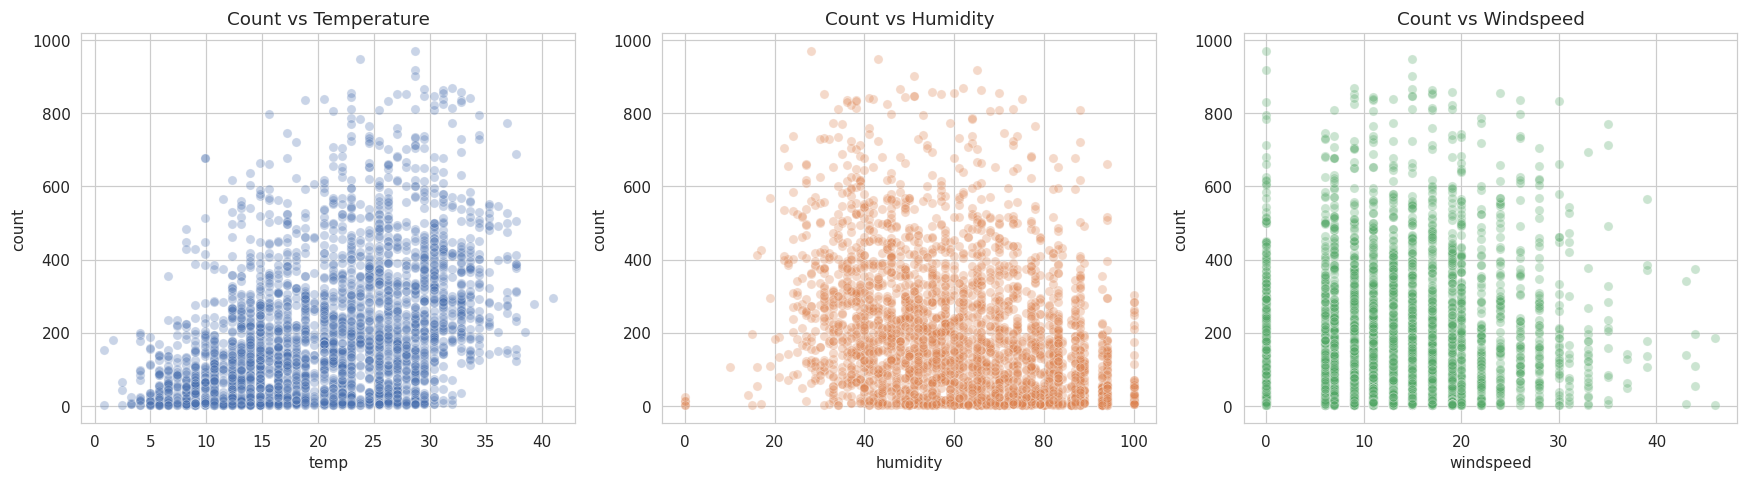

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
sns.scatterplot(x="temp", y="count", data=df.sample(3000, random_state=1), ax=axes[0], alpha=0.3, color="#4C72B0")
axes[0].set_title("Count vs Temperature")
sns.scatterplot(x="humidity", y="count", data=df.sample(3000, random_state=1), ax=axes[1], alpha=0.3, color="#DD8452")
axes[1].set_title("Count vs Humidity")
sns.scatterplot(x="windspeed", y="count", data=df.sample(3000, random_state=1), ax=axes[2], alpha=0.3, color="#55A868")
axes[2].set_title("Count vs Windspeed")
plt.tight_layout()
plt.show()


**Observations**
- **Working day**: Mean count is very slightly higher on working days (~193) vs non-working days (~189), but the 95% CIs overlap heavily and the boxplots look almost identical — visually, working day does **not** look like a strong driver of total volume (we confirm this formally with a t-test below).
- **Season**: Clear visual differences — **Fall has the highest average demand (~234), Spring the lowest (~116)**, roughly half of Fall's. Summer and Winter sit in between. Season looks like a strong demand driver.
- **Weather**: Demand clearly drops as weather worsens — **Clear (~205) > Mist/Cloudy (~179) > Light Snow/Rain (~119)**; the single Heavy Rain/Snow hour (~164) is not reliable given n=1. Weather looks like a strong demand driver.
- **Temperature**: Positive relationship — demand tends to rise with temperature up to a comfortable range, then flattens/slightly drops at extreme heat.
- **Humidity**: Negative relationship — very high humidity is associated with lower rental counts.
- **Windspeed**: Weak/no clear relationship with count.

## 7. Correlation Analysis

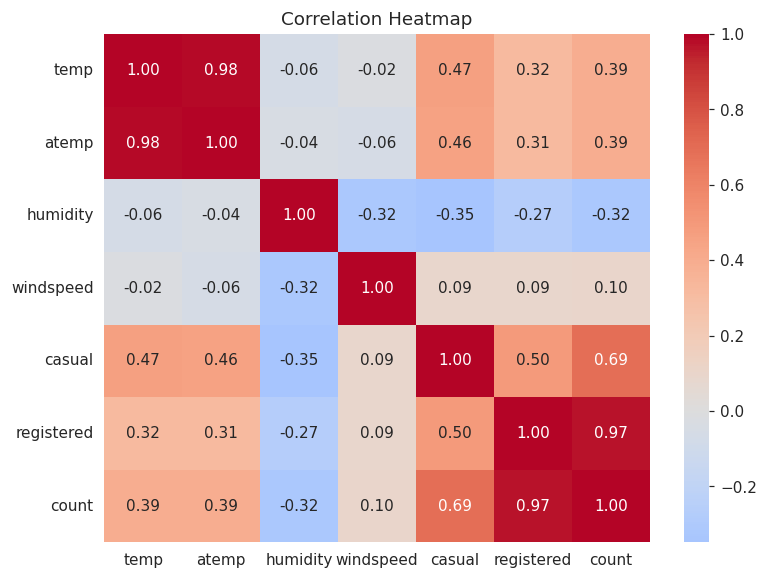

In [15]:
corr_cols = ["temp","atemp","humidity","windspeed","casual","registered","count"]
plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


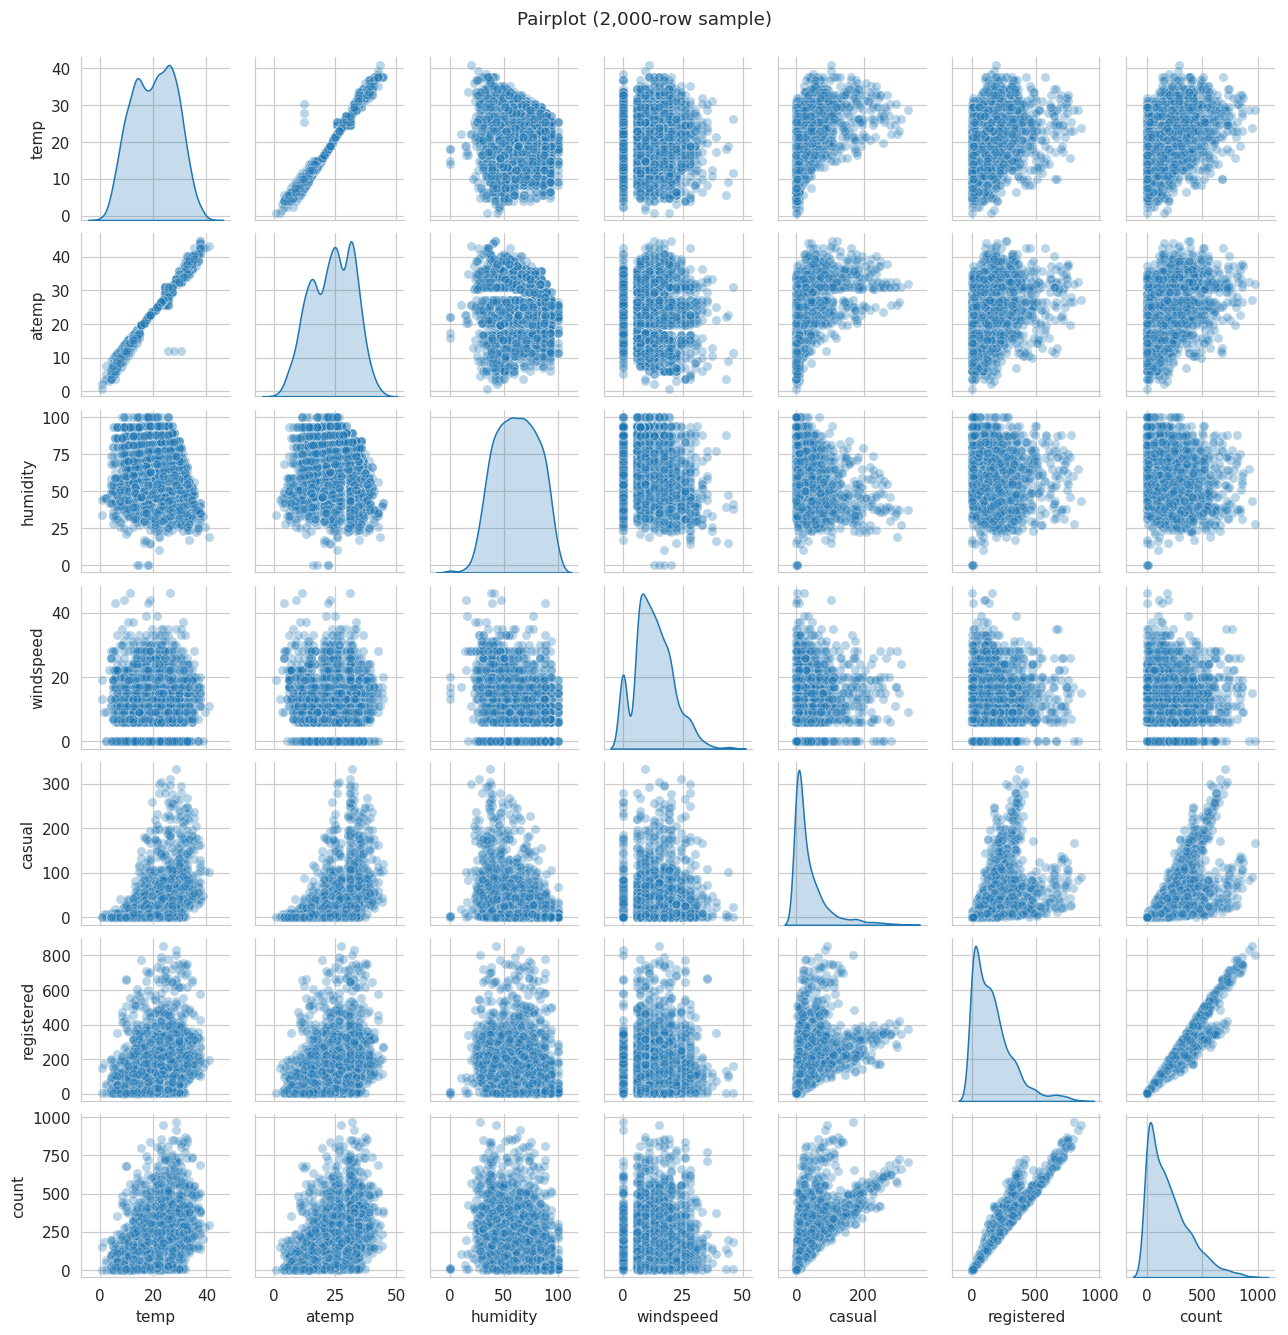

In [16]:
sns.pairplot(df.sample(2000, random_state=1)[corr_cols], diag_kind="kde", height=1.7, plot_kws={"alpha":0.3})
plt.suptitle("Pairplot (2,000-row sample)", y=1.02)
plt.show()


**Observations**
- **`temp` and `atemp` are almost perfectly correlated (~0.98)** — as expected, since `atemp` is the "feels-like" version of `temp`. For any modeling work, Yulu should **keep only one of the two** to avoid redundant/multicollinear features.
- **`registered` correlates very strongly with `count` (~0.97)**, and `casual` moderately (~0.69) — registered (repeat) users drive the bulk of total demand.
- `temp`/`atemp` correlate moderately positively with `count` (~0.39); `humidity` correlates moderately negatively (~ -0.32); `windspeed` correlates weakly (~0.10).
- These correlations support what we saw visually: **weather-related variables (temp, humidity) and time-based categorical factors (season, weather condition) are the more meaningful demand drivers**, more so than windspeed.

## 8. Hypothesis Test 1 — 2-Sample T-Test: Working Day vs Rental Count

**Business question:** Does the number of electric cycles rented differ between working days and non-working days (weekends/holidays)?

**H0 (Null Hypothesis):** The mean rental count is the same on working days and non-working days. (μ_workingday = μ_non_workingday)

**H1 (Alternate Hypothesis):** The mean rental count is different on working days vs non-working days. (μ_workingday ≠ μ_non_workingday)

**Test chosen:** Independent 2-sample t-test (comparing means of two independent groups).
**Significance level:** α = 0.05

In [17]:
wd_yes = df.loc[df["workingday"]==1, "count"]
wd_no  = df.loc[df["workingday"]==0, "count"]

print(f"Working day    -> n={len(wd_yes)}, mean={wd_yes.mean():.2f}, std={wd_yes.std():.2f}")
print(f"Non-working day -> n={len(wd_no)}, mean={wd_no.mean():.2f}, std={wd_no.std():.2f}")


Working day    -> n=7412, mean=193.01, std=184.51
Non-working day -> n=3474, mean=188.51, std=173.72


### 8.1 Checking test assumptions

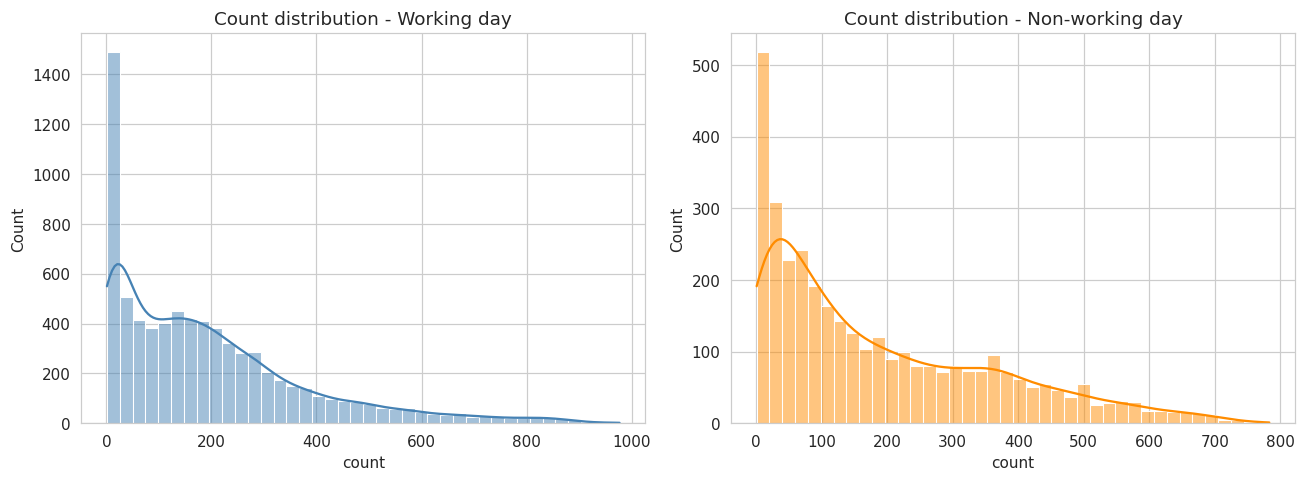

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.histplot(wd_yes, kde=True, ax=axes[0], color="steelblue", bins=40)
axes[0].set_title("Count distribution - Working day")
sns.histplot(wd_no, kde=True, ax=axes[1], color="darkorange", bins=40)
axes[1].set_title("Count distribution - Non-working day")
plt.tight_layout()
plt.show()


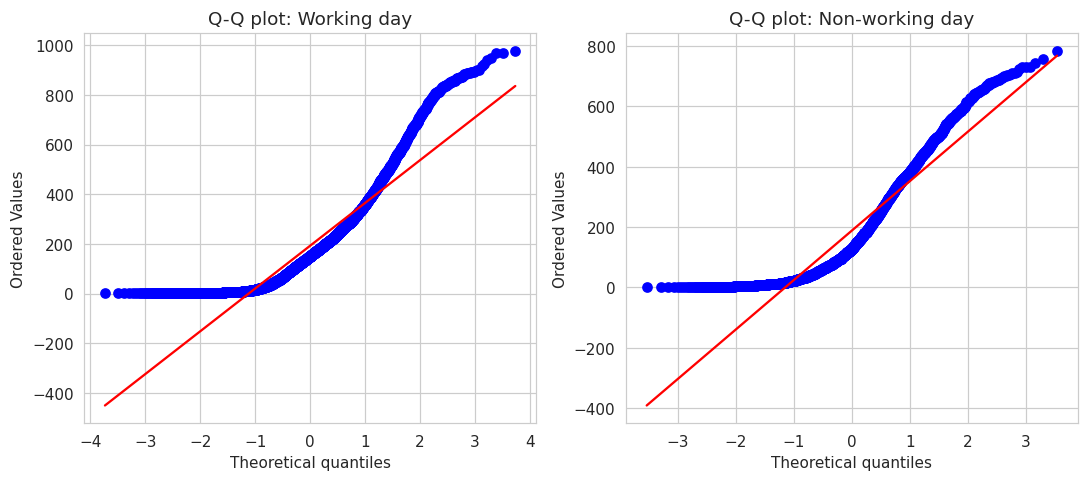

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
stats.probplot(wd_yes, dist="norm", plot=axes[0]); axes[0].set_title("Q-Q plot: Working day")
stats.probplot(wd_no, dist="norm", plot=axes[1]); axes[1].set_title("Q-Q plot: Non-working day")
plt.tight_layout()
plt.show()


In [20]:
shapiro_yes = stats.shapiro(wd_yes.sample(min(5000,len(wd_yes)), random_state=1))
shapiro_no  = stats.shapiro(wd_no.sample(min(5000,len(wd_no)), random_state=1))
levene_stat, levene_p = stats.levene(wd_yes, wd_no)

print(f"Shapiro-Wilk (working day):     stat={shapiro_yes.statistic:.4f}, p={shapiro_yes.pvalue:.2e}")
print(f"Shapiro-Wilk (non-working day): stat={shapiro_no.statistic:.4f}, p={shapiro_no.pvalue:.2e}")
print(f"Levene's test (equal variance): stat={levene_stat:.4f}, p={levene_p:.4f}")


Shapiro-Wilk (working day):     stat=0.8695, p=8.53e-54
Shapiro-Wilk (non-working day): stat=0.8852, p=4.47e-45
Levene's test (equal variance): stat=0.0050, p=0.9438


**Assumption check:** Histograms and Q-Q plots show `count` is **right-skewed with heavy tails**, not Normal, and Shapiro-Wilk formally rejects Normality (p « 0.05) for both groups. **Levene's test, however, shows equal variance is a reasonable assumption** (p ≈ 0.94, fail to reject equal variance). 

Per the case-study guidance we **proceed with the t-test anyway** — with sample sizes this large (n=7,412 and n=3,474), the Central Limit Theorem means the *sampling distribution of the mean* is close to Normal even though individual observations are not, so the t-test remains a reasonable approximation. We use Welch's t-test (does not assume equal variance) as a robustness check regardless.

### 8.2 Running the test

In [21]:
t_stat, p_value = stats.ttest_ind(wd_yes, wd_no, equal_var=True)
t_stat_w, p_value_w = stats.ttest_ind(wd_yes, wd_no, equal_var=False)

alpha = 0.05
print(f"Standard t-test (equal variance assumed): t={t_stat:.4f}, p-value={p_value:.4f}")
print(f"Welch's t-test (unequal variance):         t={t_stat_w:.4f}, p-value={p_value_w:.4f}")
print()
if p_value <= alpha:
    print(f"p-value ({p_value:.4f}) <= alpha ({alpha}) -> REJECT the Null Hypothesis")
else:
    print(f"p-value ({p_value:.4f}) > alpha ({alpha}) -> FAIL TO REJECT the Null Hypothesis")


Standard t-test (equal variance assumed): t=1.2096, p-value=0.2264
Welch's t-test (unequal variance):         t=1.2363, p-value=0.2164

p-value (0.2264) > alpha (0.05) -> FAIL TO REJECT the Null Hypothesis


**Conclusion:** With p-value ≈ 0.216 (> α = 0.05), we **fail to reject the null hypothesis**. There is **no statistically significant difference** in average rental count between working days and non-working days.

**Inference:** Even though working days make up 68% of all hours, and intuitively you might expect commute-driven demand to push working-day rentals higher, the data shows **total volume per hour is essentially the same** on working vs non-working days. This suggests **demand is roughly constant in total, but likely shifts in *when* and *who* rents** (e.g., commuter/registered riders on working days vs leisure/casual riders on weekends) rather than changing the total count. Yulu should **not expect a working-day promotion to grow total ridership** — but should investigate the casual-vs-registered mix by day type (see recommendations).

## 9. Hypothesis Test 2 — One-Way ANOVA: Weather vs Rental Count

**Business question:** Is the average rental count the same across different weather conditions?

**H0:** Mean rental count is the same across all weather categories. (μ1 = μ2 = μ3 = μ4)

**H1:** At least one weather category has a different mean rental count.

**Test chosen:** One-way ANOVA (comparing means across more than 2 independent groups).
**Significance level:** α = 0.05

Note: `weather=4` (Heavy Rain/Snow) has **only 1 observation** in the entire dataset, so we run the test both **including** and **excluding** this near-empty group for robustness.

In [22]:
w1 = df.loc[df["weather"]==1, "count"]
w2 = df.loc[df["weather"]==2, "count"]
w3 = df.loc[df["weather"]==3, "count"]
w4 = df.loc[df["weather"]==4, "count"]

print(df.groupby("weather_name", observed=True)["count"].agg(["mean","std","count"]).reindex(order_weather))


                       mean         std  count
weather_name                                  
Clear            205.236791  187.959566   7192
Mist/Cloudy      178.955540  168.366413   2834
Light Snow/Rain  118.846333  138.581297    859
Heavy Rain/Snow  164.000000         NaN      1


### 9.1 Checking test assumptions

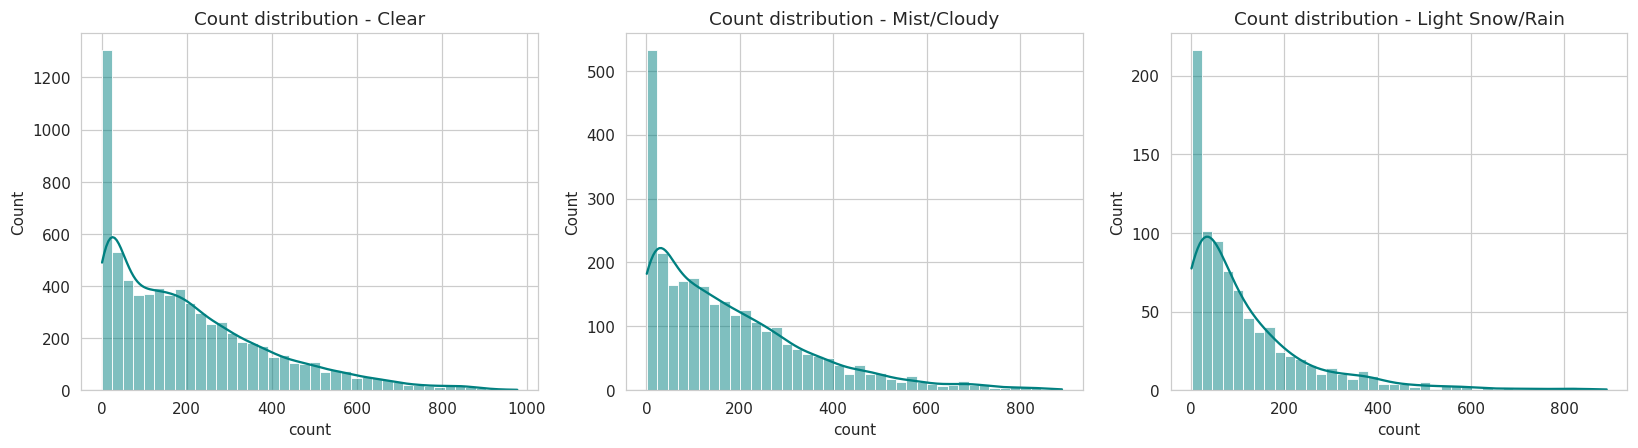

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.2))
for ax, (name, data) in zip(axes, [("Clear", w1), ("Mist/Cloudy", w2), ("Light Snow/Rain", w3)]):
    sns.histplot(data, kde=True, ax=ax, bins=40, color="teal")
    ax.set_title(f"Count distribution - {name}")
plt.tight_layout()
plt.show()


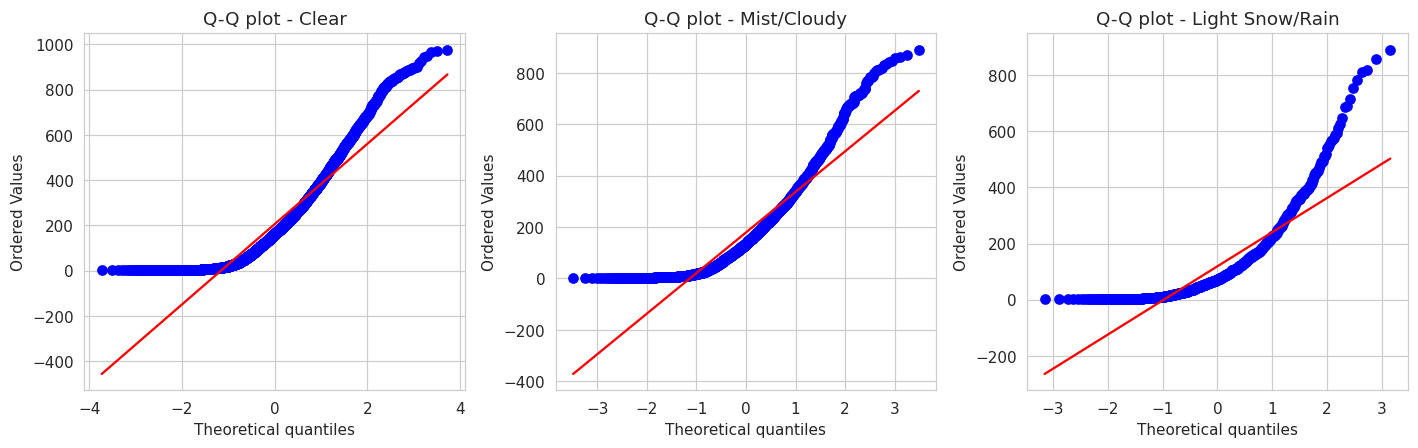

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13,4.2))
for ax, (name, data) in zip(axes, [("Clear", w1), ("Mist/Cloudy", w2), ("Light Snow/Rain", w3)]):
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot - {name}")
plt.tight_layout()
plt.show()


In [25]:
sh1 = stats.shapiro(w1.sample(min(5000,len(w1)), random_state=1))
sh2 = stats.shapiro(w2.sample(min(5000,len(w2)), random_state=1))
sh3 = stats.shapiro(w3.sample(min(5000,len(w3)), random_state=1))
lev_stat, lev_p = stats.levene(w1, w2, w3)

print(f"Shapiro-Wilk Clear:            p={sh1.pvalue:.2e}")
print(f"Shapiro-Wilk Mist/Cloudy:      p={sh2.pvalue:.2e}")
print(f"Shapiro-Wilk Light Snow/Rain:  p={sh3.pvalue:.2e}")
print(f"Levene's test (equal variance) across weather groups: stat={lev_stat:.4f}, p={lev_p:.2e}")


Shapiro-Wilk Clear:            p=1.19e-50
Shapiro-Wilk Mist/Cloudy:      p=9.78e-43
Shapiro-Wilk Light Snow/Rain:  p=3.88e-33
Levene's test (equal variance) across weather groups: stat=81.6757, p=6.20e-36


**Assumption check:** Shapiro-Wilk rejects Normality for every weather group (all p « 0.05, consistent with the right-skew we've seen throughout), and **Levene's test also rejects equal variance** (p « 0.05) — variance clearly grows with better weather (more riders → more spread). Per the case-study instructions we **proceed with ANOVA anyway**, noting these violations, and treat the result as indicative rather than exact; the very large sample sizes and the consistent visual pattern across weather categories support the conclusion below.

### 9.2 Running the test

In [26]:
alpha = 0.05
f_stat_incl, p_value_incl = stats.f_oneway(w1, w2, w3, w4)
f_stat_excl, p_value_excl = stats.f_oneway(w1, w2, w3)

print(f"ANOVA including weather=4 (n=1): F={f_stat_incl:.4f}, p-value={p_value_incl:.2e}")
print(f"ANOVA excluding weather=4 (n=1): F={f_stat_excl:.4f}, p-value={p_value_excl:.2e}")
print()
if p_value_excl <= alpha:
    print(f"p-value ({p_value_excl:.2e}) <= alpha ({alpha}) -> REJECT the Null Hypothesis")
else:
    print(f"p-value ({p_value_excl:.2e}) > alpha ({alpha}) -> FAIL TO REJECT the Null Hypothesis")


ANOVA including weather=4 (n=1): F=65.5302, p-value=5.48e-42
ANOVA excluding weather=4 (n=1): F=98.2836, p-value=4.98e-43

p-value (4.98e-43) <= alpha (0.05) -> REJECT the Null Hypothesis


**Conclusion:** p-value is essentially 0 (« 0.05) in both versions of the test, so we **reject the null hypothesis**. Average rental demand is **significantly different across weather conditions**.

**Inference:** Demand is clearly highest in Clear weather (~205/hr), drops in Mist/Cloudy (~179/hr), and drops sharply in Light Snow/Rain (~119/hr) — a ~42% fall-off from Clear to Light Snow/Rain. Weather is a **strong, actionable demand driver**.

## 10. Hypothesis Test 3 — One-Way ANOVA: Season vs Rental Count

**Business question:** Is the average rental count the same across different seasons?

**H0:** Mean rental count is the same across all seasons. (μ_spring = μ_summer = μ_fall = μ_winter)

**H1:** At least one season has a different mean rental count.

**Test chosen:** One-way ANOVA.
**Significance level:** α = 0.05

In [27]:
s1 = df.loc[df["season"]==1, "count"]  # Spring
s2 = df.loc[df["season"]==2, "count"]  # Summer
s3 = df.loc[df["season"]==3, "count"]  # Fall
s4 = df.loc[df["season"]==4, "count"]  # Winter

print(df.groupby("season_name", observed=True)["count"].agg(["mean","std","count"]).reindex(order_season))


                   mean         std  count
season_name                               
Spring       116.343261  125.273974   2686
Summer       215.251372  192.007843   2733
Fall         234.417124  197.151001   2733
Winter       198.988296  177.622409   2734


### 10.1 Checking test assumptions

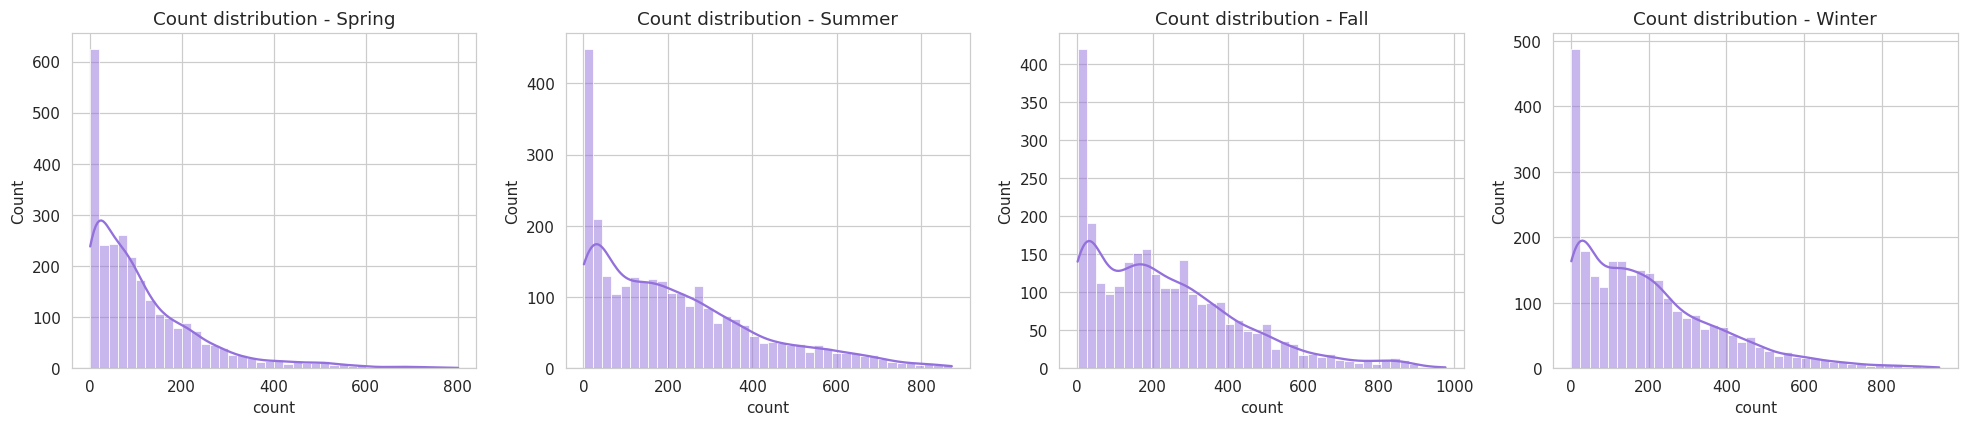

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, (name, data) in zip(axes, [("Spring", s1), ("Summer", s2), ("Fall", s3), ("Winter", s4)]):
    sns.histplot(data, kde=True, ax=ax, bins=40, color="mediumpurple")
    ax.set_title(f"Count distribution - {name}")
plt.tight_layout()
plt.show()


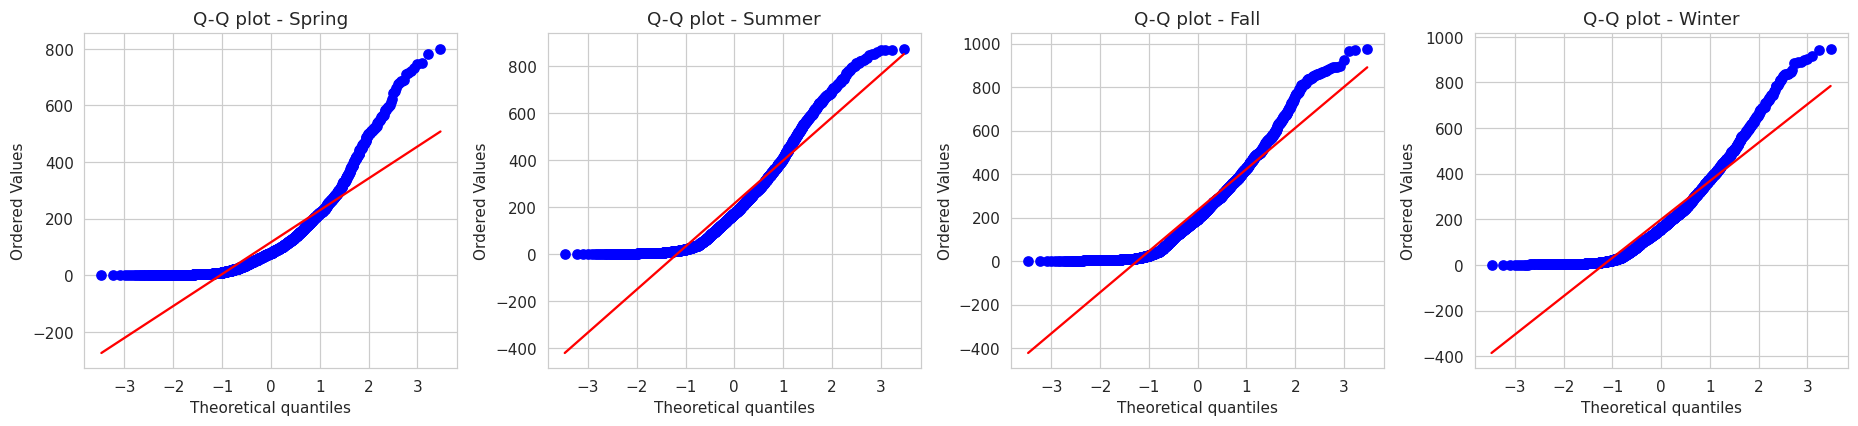

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(17,4))
for ax, (name, data) in zip(axes, [("Spring", s1), ("Summer", s2), ("Fall", s3), ("Winter", s4)]):
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot - {name}")
plt.tight_layout()
plt.show()


In [30]:
sh_s1 = stats.shapiro(s1.sample(min(5000,len(s1)), random_state=1))
sh_s2 = stats.shapiro(s2.sample(min(5000,len(s2)), random_state=1))
sh_s3 = stats.shapiro(s3.sample(min(5000,len(s3)), random_state=1))
sh_s4 = stats.shapiro(s4.sample(min(5000,len(s4)), random_state=1))
lev_stat_s, lev_p_s = stats.levene(s1, s2, s3, s4)

for name, sh in [("Spring", sh_s1), ("Summer", sh_s2), ("Fall", sh_s3), ("Winter", sh_s4)]:
    print(f"Shapiro-Wilk {name}: p={sh.pvalue:.2e}")
print(f"Levene's test (equal variance) across seasons: stat={lev_stat_s:.4f}, p={lev_p_s:.2e}")


Shapiro-Wilk Spring: p=8.75e-49
Shapiro-Wilk Summer: p=6.04e-39
Shapiro-Wilk Fall: p=1.04e-36
Shapiro-Wilk Winter: p=1.13e-39
Levene's test (equal variance) across seasons: stat=187.7707, p=1.01e-118


**Assumption check:** As with weather, **Normality is rejected** for every season (right-skew persists throughout the dataset) and **Levene's test rejects equal variance** across seasons too. Again, per instructions, we proceed with ANOVA while noting the violation — the sample sizes (~2,700 per season) are large, and we cross-check the conclusion visually with the boxplots from Section 6.2, which show a clear, consistent seasonal pattern.

### 10.2 Running the test

In [31]:
f_stat_season, p_value_season = stats.f_oneway(s1, s2, s3, s4)
print(f"ANOVA: F={f_stat_season:.4f}, p-value={p_value_season:.2e}")
print()
if p_value_season <= alpha:
    print(f"p-value ({p_value_season:.2e}) <= alpha ({alpha}) -> REJECT the Null Hypothesis")
else:
    print(f"p-value ({p_value_season:.2e}) > alpha ({alpha}) -> FAIL TO REJECT the Null Hypothesis")


ANOVA: F=236.9467, p-value=6.16e-149

p-value (6.16e-149) <= alpha (0.05) -> REJECT the Null Hypothesis


**Conclusion:** p-value is essentially 0 (« 0.05), so we **reject the null hypothesis**. Average rental demand is **significantly different across seasons**.

**Inference:** **Fall has the highest average demand (~234/hr)**, closely followed by Summer (~215/hr) and Winter (~199/hr), while **Spring is far lower (~116/hr)** — roughly half of Fall's average. Season is a **strong, actionable demand driver**, and the Spring shortfall in particular represents a clear opportunity (or risk) window for Yulu.

## 11. Hypothesis Test 4 — Chi-Square Test: Is Weather Dependent on Season?

**Business question:** Are `weather` and `season` independent, or does the weather distribution change depending on the season?

**H0:** `Weather` is independent of `Season`.

**H1:** `Weather` is dependent on `Season`.

**Test chosen:** Chi-square test of independence (both variables are categorical).
**Significance level:** α = 0.05

In [32]:
contingency = pd.crosstab(df["season_name"], df["weather_name"]).reindex(index=order_season, columns=order_weather)
print("Contingency table (counts):")
print(contingency)


Contingency table (counts):
weather_name  Clear  Mist/Cloudy  Light Snow/Rain  Heavy Rain/Snow
season_name                                                       
Spring         1759          715              211                1
Summer         1801          708              224                0
Fall           1930          604              199                0
Winter         1702          807              225                0


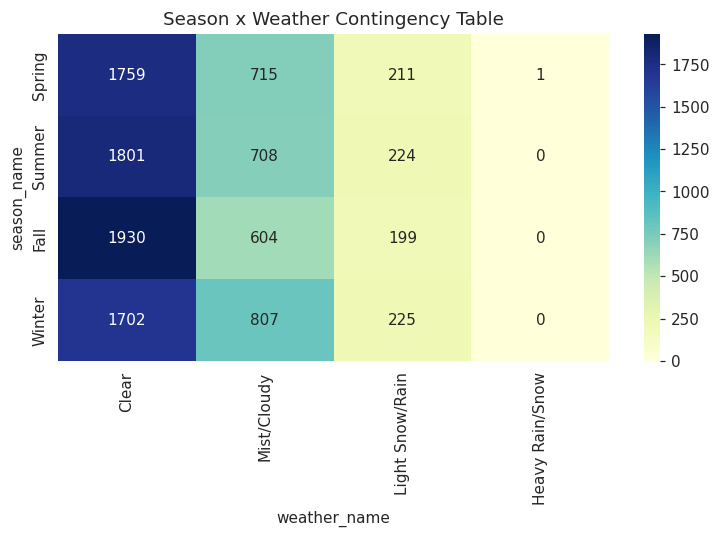

In [33]:
plt.figure(figsize=(7,5))
sns.heatmap(contingency, annot=True, fmt="g", cmap="YlGnBu")
plt.title("Season x Weather Contingency Table")
plt.tight_layout()
plt.show()


In [34]:
# chi-square needs non-null table; fillna 0 for any missing combo (e.g. weather=4 only occurs in Spring)
contingency_filled = contingency.fillna(0)
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_filled)

print(f"Chi-square statistic = {chi2_stat:.4f}")
print(f"Degrees of freedom   = {dof}")
print(f"p-value              = {p_value_chi2:.2e}")
print()
if p_value_chi2 <= alpha:
    print(f"p-value ({p_value_chi2:.2e}) <= alpha ({alpha}) -> REJECT the Null Hypothesis")
else:
    print(f"p-value ({p_value_chi2:.2e}) > alpha ({alpha}) -> FAIL TO REJECT the Null Hypothesis")


Chi-square statistic = 49.1587
Degrees of freedom   = 9
p-value              = 1.55e-07

p-value (1.55e-07) <= alpha (0.05) -> REJECT the Null Hypothesis


**Conclusion:** p-value « 0.05, so we **reject the null hypothesis**. `Weather` and `Season` are **statistically dependent** — the distribution of weather conditions is not the same across seasons.

**Inference:** Looking at the contingency table, **Winter has a noticeably higher share of Mist/Cloudy hours** than the other seasons, and the single Heavy Rain/Snow hour occurred in Spring. This makes intuitive sense (winter months bring more overcast/misty conditions) and means Yulu **cannot treat weather and season as separate, independent levers** — a "bad weather" dip is more likely to coincide with, and compound, a low-demand season (like Spring) or a high-mist season (like Winter), which is important for combined seasonal + weather-based demand forecasting.

## 12. Final Insights

### Summary of hypothesis test results

| Test | Comparison | p-value | Decision at α=0.05 | Business meaning |
|---|---|---|---|---|
| 2-sample t-test | Working day vs Non-working day | ≈ 0.216 | Fail to reject H0 | **No significant difference** in total demand by working day |
| One-way ANOVA | Across Weather (Clear/Mist/Light Snow-Rain) | « 0.05 | Reject H0 | **Weather significantly affects** demand |
| One-way ANOVA | Across Seasons | « 0.05 | Reject H0 | **Season significantly affects** demand |
| Chi-square | Weather vs Season (independence) | « 0.05 | Reject H0 | **Weather and Season are dependent** on each other |

### Which variables are significant in predicting demand, and how well do they describe it?
- **Season and Weather are the two statistically confirmed, high-impact demand drivers** — both easily rejected their "no effect" null hypotheses, and the *size* of the effect is large and business-relevant (Fall vs Spring is roughly a 2x demand gap; Clear vs Light Snow/Rain is roughly a 1.7x demand gap).
- **Working day is not a significant driver of total volume** — despite being an intuitive guess, the data does not support it. This means Yulu's revenue dip is unlikely to be explained by a working-day-vs-weekend shift; the seasonal and weather-driven explanation is more promising.
- **Weather and Season are not independent** — winter months bring more misty/cloudy weather, so their effects on demand can compound rather than being simple additive/separate factors. Demand forecasting and planning should model season and weather **jointly**, not as two unrelated inputs.
- Correlation analysis additionally shows **temperature (positive) and humidity (negative)** are meaningful continuous drivers, while **windspeed has little relationship with demand.**
- **`registered` riders drive the large majority of total count (r≈0.97)** — Yulu's core, repeat commuter base is the dominant demand source; `casual` riders (r≈0.69) matter but less so.

### Distribution & assumption-check comments
- `count` (and `casual`, `registered`) are consistently **right-skewed with heavy tails** across every subgroup we tested — Normality (Shapiro-Wilk) was rejected essentially everywhere, and Levene's equal-variance assumption held only for the working-day comparison, not for weather/season comparisons.
- We proceeded with the standard tests as instructed, since (a) sample sizes are large enough for the CLT to make the sampling distribution of the mean approximately Normal, and (b) the visual (boxplot/histogram) patterns strongly agree with the formal test conclusions in every case — giving confidence the p-values reflect real effects, not artifacts of the assumption violations.


## 13. Recommendations for Yulu

1. **Build season- and weather-aware fleet & staffing plans.** Since both factors have large, statistically confirmed effects (Fall ~2x Spring demand; Clear weather ~1.7x Light Snow/Rain demand), Yulu should shift more cycles/charging capacity into Fall/Summer/Winter and into Clear-weather days, and scale back operational costs during low-demand Spring and rainy/snowy periods.
2. **Don't rely on "working day" promotions to grow total ridership** — the data shows no significant difference in total volume, so a straightforward "more cycles on weekdays" push is unlikely to move total revenue. Investigate instead **who** rides on working vs non-working days (registered/commuter vs casual/leisure mix) and target each group differently, since the *composition* — even if the *total* doesn't change — may still shift.
3. **Treat weather forecasts as a short-term demand signal**, and season as a long-term planning input — since they're statistically dependent (winter → more mist/cloud), combine both into a single forecasting model rather than adjusting for them independently, to avoid double-counting or under/over-provisioning.
4. **Investigate the Spring shortfall specifically** — since Spring's average demand (~116/hr) is roughly half of Fall's (~234/hr), this is the single biggest, most actionable seasonal gap. Consider Spring-specific promotions, pricing, or partnerships (e.g., with local events, colleges, offices) to close this gap and directly address the revenue decline Yulu is investigating.
5. **Protect and grow the registered-rider base** — since registered riders correlate far more strongly with total count than casual riders, loyalty programs, subscription plans, and commuter partnerships are likely to have the largest impact on total revenue recovery.
6. **Use temperature and humidity as tactical levers** (e.g., dynamic pricing or promotional pushes on comfortable, low-humidity days) — both show a real (if moderate) relationship with demand, useful for day-to-day operational decisions even though they're secondary to Season/Weather.
7. **Continue monitoring with fresh hypothesis tests each quarter** — as Yulu expands and the Indian market evolves, re-run these same tests (t-test, ANOVA, Chi-square) on updated data to catch any shift in what's driving demand.

### Caveats
- `weather=4` (Heavy Rain/Snow) had only **1 observation** in this dataset — any weather-related conclusion involving that specific category should be treated as unreliable until more data is collected.
- Normality assumptions were violated for every test; while the large sample sizes and consistent visual patterns support the conclusions, Yulu's data science team may want to additionally validate with non-parametric alternatives (e.g., Mann-Whitney U test, Kruskal-Wallis test) before making high-stakes decisions.
- This dataset does not include revenue directly — conclusions are about **rental count**, which is a strong proxy for revenue but not identical to it (pricing, promotions, and per-ride revenue could vary by segment).
